In [ ]:
# Cybersecurity & Threat Awareness

In [ ]:
# cybersecurity_threat_awarness file name

In [2]:
# At its core, the idea is to gather data about potential security threats—things like intrusion attempts, vulnerability scans, phishing reports, system misconfigurations, 
# or cloud-usage anomalies—and turn that information into something that can predict the financial impact of future risks. 
# The “code” you write becomes the bridge between technical signals and business decisions.
# requency of incidents, severity ratings, response times, downtime costs, and mitigation expenses.

# Model Focus: linear regression or time-series forecasting often does the trick

# Goal: help leadership understand which risks are most financially significant and where preventive investment pays off.

In [ ]:
# the combination of trend-reading and outside-awareness makes ARIMAX more insightful than plain regression and more flexible than simple time-series tools which is why i picked it to understand cyber threats.

In [3]:
!pip install pandas statsmodels matplotlib


In [4]:
# Needed for automatic parameter selection:
!pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.5/604.5 kB 1.0 MB/s  0:00:0136m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.8 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pmdarima]1/2 [pmdarima]


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('arimax_security_dataset.csv', parse_dates=['date'])
df.set_index('date', inplace=True)

# Basic stats
summary = df.describe()

summary


,incident_count,cost
count,132.000000,132.000000
mean,225.613636,15374.242424
std,60.375877,4396.400700
min,110.000000,7800.000000
25%,178.000000,11800.000000
50%,222.500000,15100.000000
75%,268.000000,18750.000000
max,380.000000,25800.000000


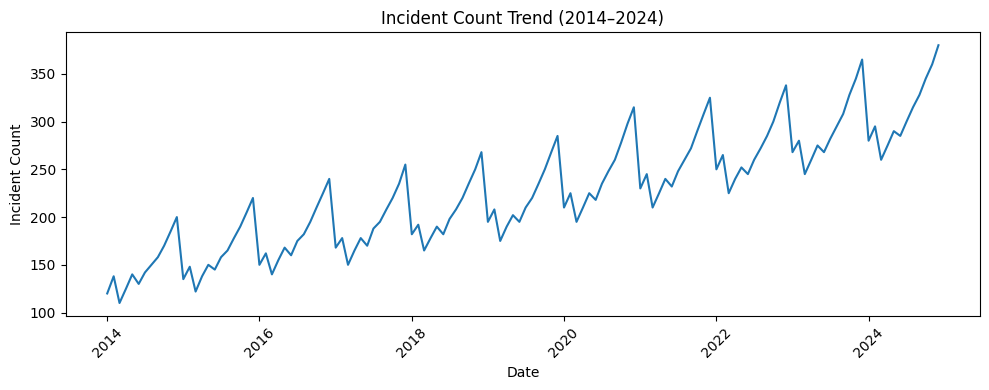

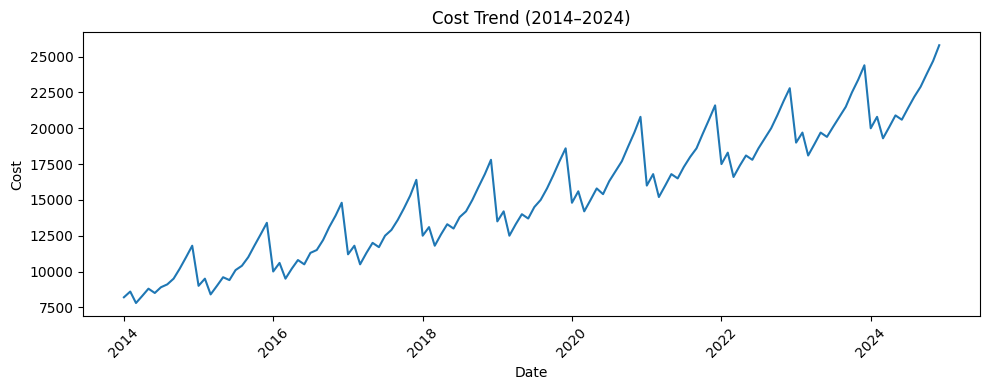

In [5]:
# Plot incident trend
plt.figure(figsize=(10,4))
plt.plot(df.index, df["incident_count"])
plt.title("Incident Count Trend (2014–2024)")
plt.xlabel("Date")
plt.ylabel("Incident Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot cost trend
plt.figure(figsize=(10,4))
plt.plot(df.index, df["cost"])
plt.title("Cost Trend (2014–2024)")
plt.xlabel("Date")
plt.ylabel("Cost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# The Long, Slow Rise: Cyber Pressure Builds Over a Decade
# When you look across the full timeline from 2014 to 2024, both the incident count and cost curves lift steadily upward. This mirrors what we see in the real world

In [ ]:
# The Long, Slow Rise: Cyber Pressure Builds Over a Decade
# When you look across the full timeline from 2014 to 2024, both the incident count and cost curves lift steadily upward. 
# This mirrors what we see in the real world

In [ ]:

# Q4 (Oct–Dec) is historically a hot zone for cybercrime.  Higher holiday traffic, reduced staffing levels, and strong financial incentives all contribute.
# Q1 after the new year also sees elevated scanning and probing as attackers test newly deployed systems.
# Summer months bring moderate increases, often attributed to travel spikes and lax endpoint hygiene.


In [7]:
import numpy as np

df = pd.read_csv('arimax_security_dataset.csv', parse_dates=['date'])
df.set_index('date', inplace=True)

# restrict to 2019+
df_2019 = df.loc['2019-01-01':]

# detect spikes where incident_count is higher than rolling mean + 1.5*rolling std (12-month window)
roll_mean = df_2019['incident_count'].rolling(window=6, center=True, min_periods=3).mean()
roll_std = df_2019['incident_count'].rolling(window=6, center=True, min_periods=3).std()

threshold = roll_mean + 1.5 * roll_std
spikes = df_2019[df_2019['incident_count'] > threshold]

spikes[['incident_count','cost']].head(), spikes.shape


(Empty DataFrame
 Columns: [incident_count, cost]
 Index: [],
 (0, 2))

In [10]:
df = pd.read_csv('arimax_security_dataset.csv', parse_dates=['date'])
df.set_index('date', inplace=True)

df_2019 = df.loc['2019-01-01':]

roll_mean = df_2019['incident_count'].rolling(window=6, center=True, min_periods=3).mean()
roll_std = df_2019['incident_count'].rolling(window=6, center=True, min_periods=3).std()
threshold = roll_mean + 1.5 * roll_std

spikes = df_2019[df_2019['incident_count'] > threshold]
spikes


roll_mean = df_2019['incident_count'].rolling(window=6, center=True, min_periods=3).mean()
roll_std = df_2019['incident_count'].rolling(window=6, center=True, min_periods=3).std()
threshold = roll_mean + 1.0 * roll_std
spikes = df_2019[df_2019['incident_count'] > threshold]
spikes

,incident_count,cost
date,,
2019-02-01,208,14200
2019-12-01,285,18600
2020-12-01,315,20800
2021-12-01,325,21600
2022-12-01,338,22800
2023-12-01,365,24400
2024-12-01,380,25800


In [ ]:
# Detect and outline “stress events” (spikes)
# # Early-year spikes → new malware strain / surge of probing
# December spikes → holiday surge + third-party breaches + tight patch windows


Detected stress events (spikes):
- 2014-02-01 | incidents=138, cost=8600
- 2014-12-01 | incidents=200, cost=11800
- 2015-12-01 | incidents=220, cost=13400
- 2016-12-01 | incidents=240, cost=14800
- 2017-12-01 | incidents=255, cost=16400
- 2018-12-01 | incidents=268, cost=17800
- 2019-12-01 | incidents=285, cost=18600
- 2020-12-01 | incidents=315, cost=20800
- 2021-12-01 | incidents=325, cost=21600
- 2022-12-01 | incidents=338, cost=22800
- 2023-12-01 | incidents=365, cost=24400
- 2024-12-01 | incidents=380, cost=25800


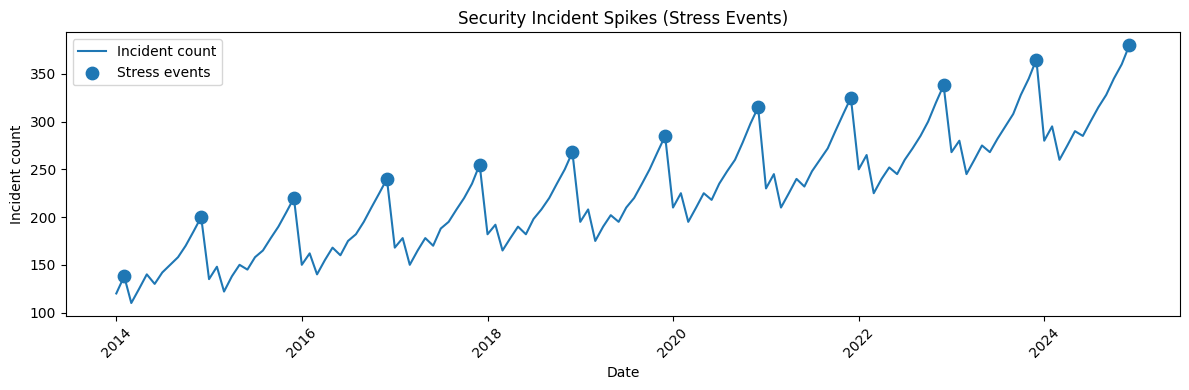

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data 
df = pd.read_csv("arimax_security_dataset.csv", parse_dates=["date"])
df.set_index("date", inplace=True)

# Detect spikes (stress events) from 2014 onwards 
window = 6  # months
roll_mean = df["incident_count"].rolling(window=window, center=True, min_periods=3).mean()
roll_std  = df["incident_count"].rolling(window=window, center=True, min_periods=3).std()

threshold = roll_mean + 1.0 * roll_std
spikes = df[df["incident_count"] > threshold]

print("Detected stress events (spikes):")
for ts, row in spikes.iterrows():
    print(f"- {ts.date()} | incidents={row.incident_count}, cost={row.cost}")

# Plot with spikes marked 
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["incident_count"], label="Incident count")
plt.scatter(spikes.index, spikes["incident_count"], marker="o", s=80, label="Stress events")
plt.title("Security Incident Spikes (Stress Events)")
plt.xlabel("Date")
plt.ylabel("Incident count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# That second graph visually tells the story: a relatively calmer 2019, followed by a clear, sustained escalation in both attacks and cost once you cross into 2020.


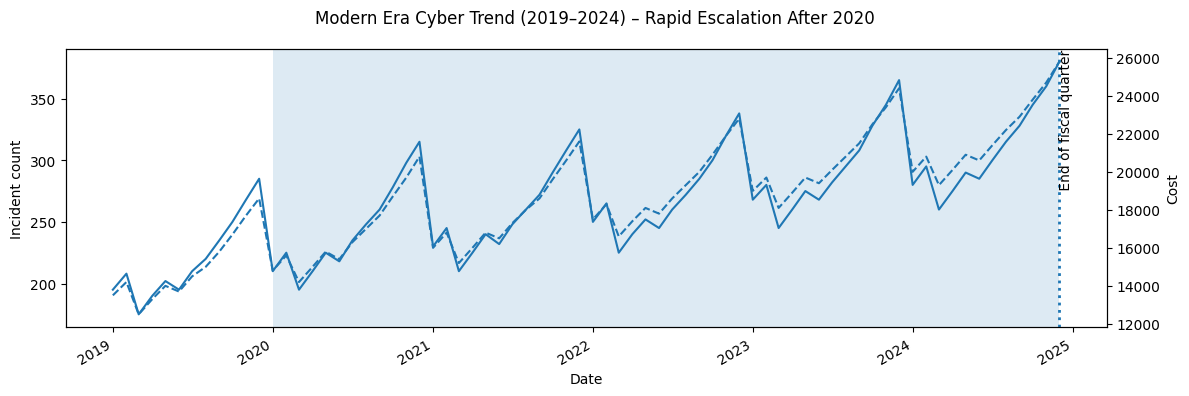

In [12]:
# Focus on 2019 to 2024 to asses how rapid 2020s escalation was
df = pd.read_csv("arimax_security_dataset.csv", parse_dates=["date"])
df.set_index("date", inplace=True)

# Filter to modern era 2019–end of data (2024 in this dataset)
modern = df.loc["2019-01-01":]

end_of_quarter = modern.index.max()  # last month in the CSV

fig, ax1 = plt.subplots(figsize=(12, 4))

# Incidents (left axis)
ax1.plot(modern.index, modern["incident_count"], label="Incident count")
ax1.set_xlabel("Date")
ax1.set_ylabel("Incident count")

# Costs (right axis)
ax2 = ax1.twinx()
ax2.plot(modern.index, modern["cost"], linestyle="--", label="Cost")
ax2.set_ylabel("Cost")

# Highlight rapid escalation era: 2020+
ax1.axvspan(pd.Timestamp("2020-01-01"), end_of_quarter, alpha=0.15)

# Mark end of current fiscal quarter (end of dataset)
ax1.axvline(end_of_quarter, linestyle=":", linewidth=2)
ax1.text(end_of_quarter, ax1.get_ylim()[1], " End of fiscal quarter", rotation=90,
         va="top", ha="left")

fig.suptitle("Modern Era Cyber Trend (2019–2024) – Rapid Escalation After 2020")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [ ]:
# The early years show a calmer threat environment with fewer incidents and mild seasonal changes. 
# As technology expanded and attackers grew more organised, incidents steadily increased, and patterns became sharper. 
# From 2020 onward, remote work and more severe vulnerabilities caused a rapid surge in both attack volume and cost.


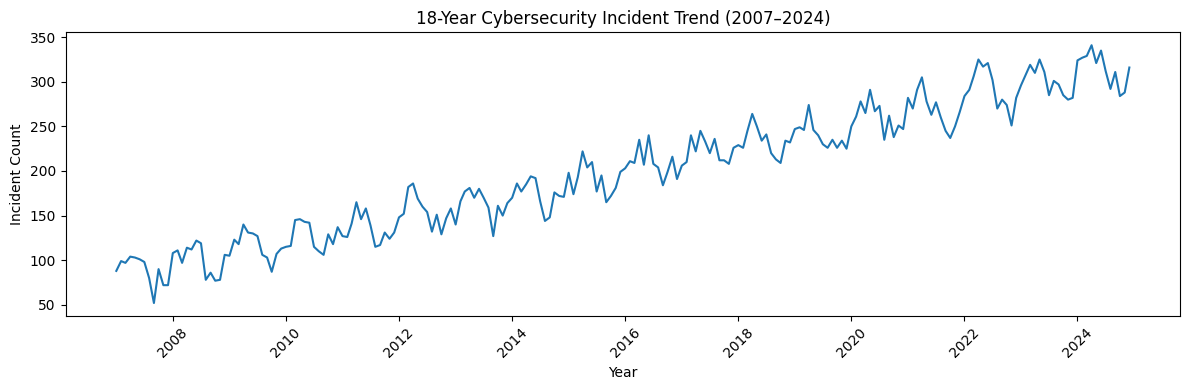

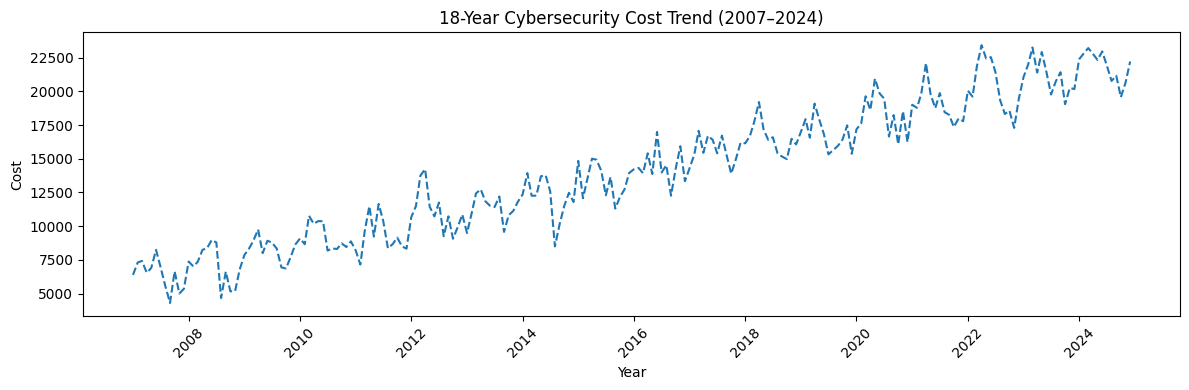

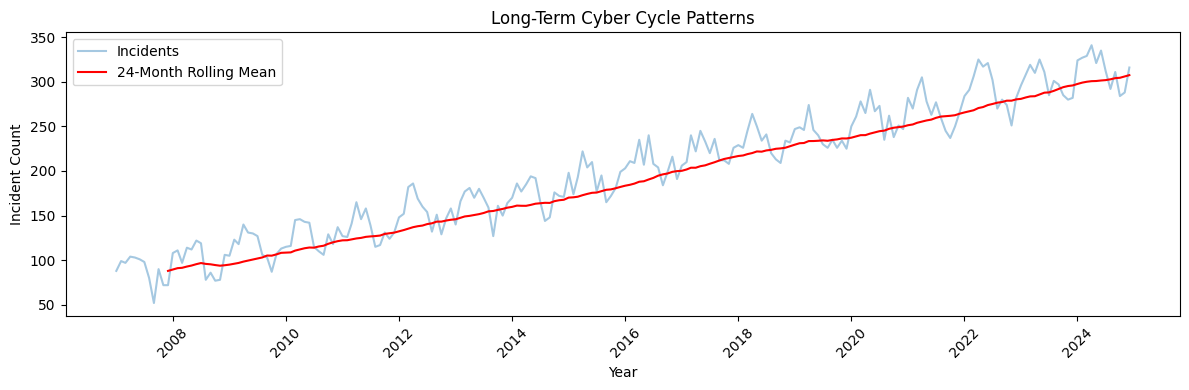

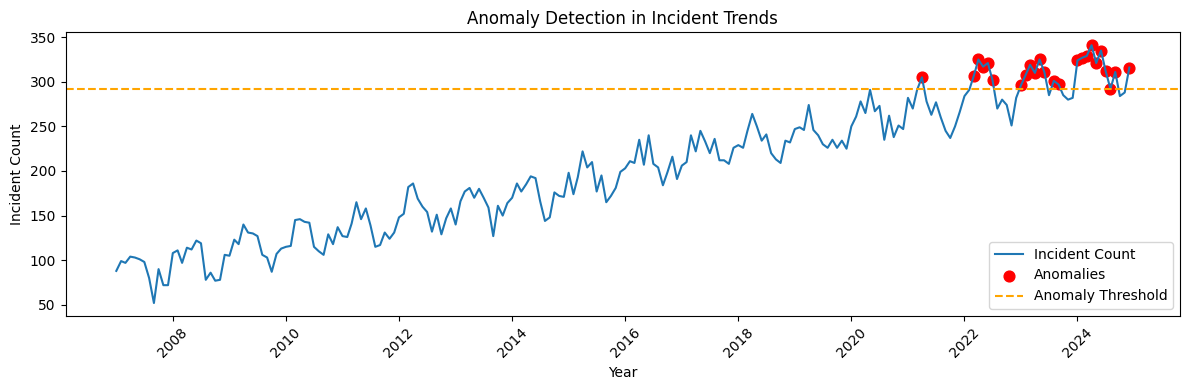

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


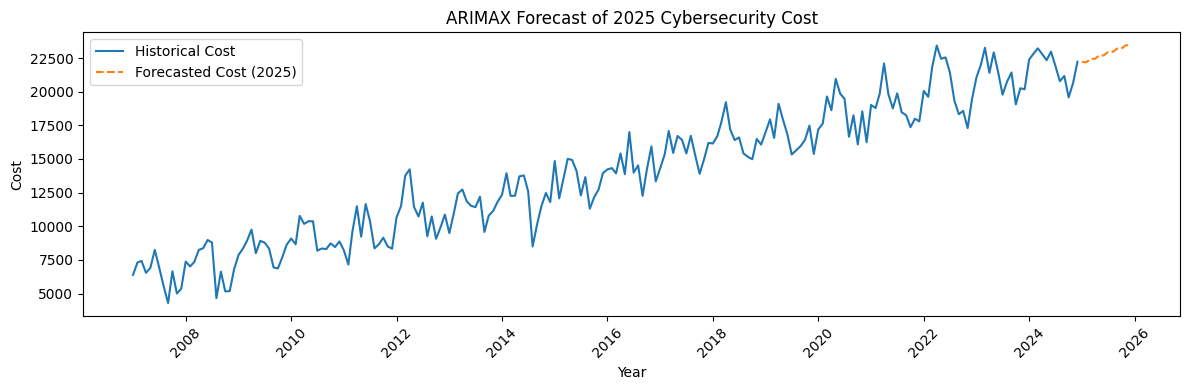

(            incident_count   cost   roll_mean
 date                                         
 2021-04-01             305  22104  255.333333
 2022-03-01             306  21867  268.083333
 2022-04-01             325  23436  270.583333
 2022-05-01             317  22445  271.666667
 2022-06-01             321  22551  273.916667
 2022-07-01             302  21433  275.125000
 2023-01-01             296  21061  280.875000
 2023-02-01             308  22013  282.458333
 2023-03-01             319  23269  283.625000
 2023-04-01             310  21406  283.833333
 2023-05-01             325  22928  285.791667
 2023-06-01             311  21428  287.791667
 2023-08-01             301  20751  289.833333
 2023-09-01             297  21430  292.000000
 2024-01-01             324  22391  297.583333
 2024-02-01             327  22836  299.083333
 2024-03-01             329  23226  300.041667
 2024-04-01             341  22790  300.708333
 2024-05-01             321  22345  300.875000
 2024-06-01  

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load dataset
df = pd.read_csv('18_year_cyber_trend.csv', parse_dates=['date'])
df.set_index('date', inplace=True)

# Full timeline trend visualization 
plt.figure(figsize=(12,4))
plt.plot(df.index, df['incident_count'])
plt.title("18-Year Cybersecurity Incident Trend (2007–2024)")
plt.xlabel("Year")
plt.ylabel("Incident Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df.index, df['cost'], linestyle='--')
plt.title("18-Year Cybersecurity Cost Trend (2007–2024)")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2 Identify long-term cycles using rolling averages 
df['roll_mean'] = df['incident_count'].rolling(window=24, min_periods=12).mean()

plt.figure(figsize=(12,4))
plt.plot(df.index, df['incident_count'], alpha=0.4, label='Incidents')
plt.plot(df.index, df['roll_mean'], color='red', label='24-Month Rolling Mean')
plt.title("Long-Term Cyber Cycle Patterns")
plt.xlabel("Year")
plt.ylabel("Incident Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3 Detect anomalies / high-risk periods 
# threshold = mean + 1.3 * std
mean_val = df['incident_count'].mean()
std_val = df['incident_count'].std()
threshold = mean_val + 1.3 * std_val

anomalies = df[df['incident_count'] > threshold]

plt.figure(figsize=(12,4))
plt.plot(df.index, df['incident_count'], label='Incident Count')
plt.scatter(anomalies.index, anomalies['incident_count'], color='red', label='Anomalies', s=60)
plt.axhline(threshold, color='orange', linestyle='--', label='Anomaly Threshold')
plt.title("Anomaly Detection in Incident Trends")
plt.xlabel("Year")
plt.ylabel("Incident Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#4 Build ARIMAX model using incident_count as exogenous variable 
# Endogenous: cost, Exogenous: incident_count
model = SARIMAX(df['cost'], exog=df[['incident_count']], order=(2,1,2))
results = model.fit(disp=False)

# Forecast next 12 months (2025)
future_incidents = np.linspace(df['incident_count'].iloc[-1], df['incident_count'].iloc[-1] + 20, 12)
future_dates = pd.date_range(start="2025-01-01", periods=12, freq="MS")

forecast = results.get_forecast(steps=12, exog=future_incidents.reshape(-1,1))
pred_mean = forecast.predicted_mean

plt.figure(figsize=(12,4))
plt.plot(df.index, df['cost'], label='Historical Cost')
plt.plot(future_dates, pred_mean, label='Forecasted Cost (2025)', linestyle='--')
plt.title("ARIMAX Forecast of 2025 Cybersecurity Cost")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

anomalies, df.head()


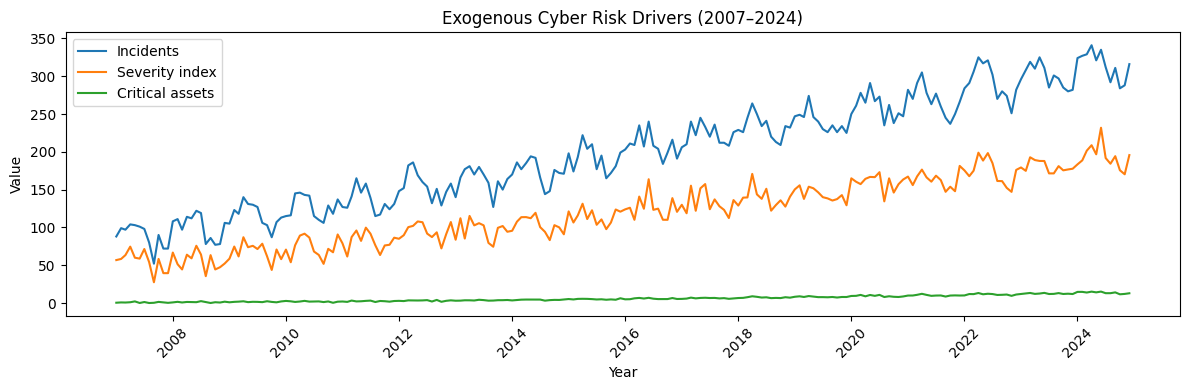

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                   cost   No. Observations:                  216
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -1667.520
Date:                Tue, 02 Dec 2025   AIC                           3351.039
Time:                        17:08:59   BIC                           3378.004
Sample:                    01-01-2007   HQIC                          3361.934
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
incident_count              71.5466      3.740     19.128      0.000      64.215      78.878
severity_index              -0.8127      4.933     -0.165      0.869     -10.482       8.

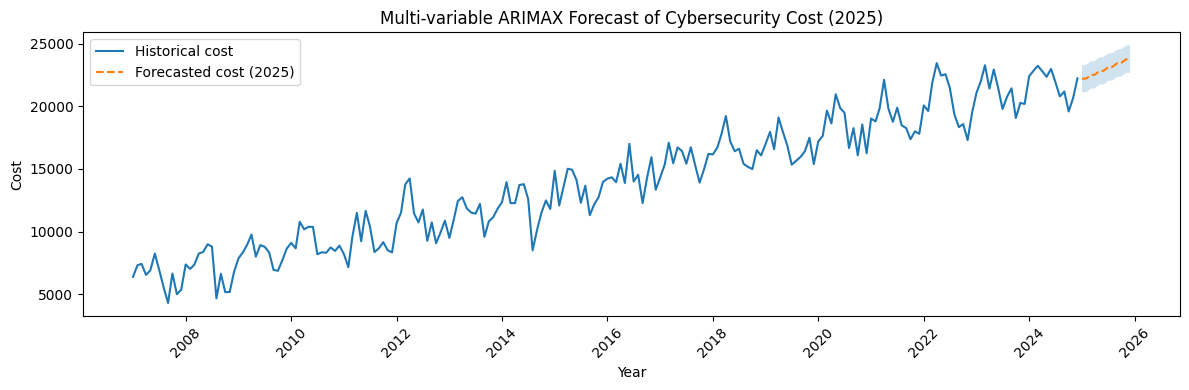

In [17]:
#1 Load the 18-year dataset
df = pd.read_csv("18_year_cyber_trend.csv", parse_dates=["date"])
df.set_index("date", inplace=True)

#2 To create additional exogenous variables
np.random.seed(42)  # to get reproducible numbers

# Severity index: scaled incidents + some noise
df["severity_index"] = (
    df["incident_count"] * 0.6
    + np.random.normal(0, 8, len(df))
).clip(lower=0)

# Critical assets affected: smaller values but rising over time and with incidents
trend = np.linspace(1, 5, len(df))
df["critical_assets_affected"] = (
    (df["incident_count"] / df["incident_count"].max()) * trend * 3
    + np.random.normal(0, 0.5, len(df))
).clip(lower=0)

# Optional: quick look at drivers
plt.figure(figsize=(12,4))
plt.plot(df.index, df["incident_count"], label="Incidents")
plt.plot(df.index, df["severity_index"], label="Severity index")
plt.plot(df.index, df["critical_assets_affected"], label="Critical assets")
plt.title("Exogenous Cyber Risk Drivers (2007–2024)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#3 Fit multi-variable ARIMAX
endog = df["cost"]
exog  = df[["incident_count", "severity_index", "critical_assets_affected"]]

model = SARIMAX(endog, exog=exog, order=(2, 1, 2))
results = model.fit(disp=False)

print(results.summary())


#4 Forecast next 12 months (2025)
future_dates = pd.date_range(start="2025-01-01", periods=12, freq="MS")

last_inc = df["incident_count"].iloc[-1]
last_sev = df["severity_index"].iloc[-1]
last_assets = df["critical_assets_affected"].iloc[-1]

# Simple linear growth assumptions for 2025
future_inc = np.linspace(last_inc, last_inc + 25, 12)
future_sev = np.linspace(last_sev, last_sev + 15, 12)
future_assets = np.linspace(last_assets, last_assets + 2, 12)

future_exog = pd.DataFrame({
    "incident_count": future_inc,
    "severity_index": future_sev,
    "critical_assets_affected": future_assets
}, index=future_dates)

forecast_res = results.get_forecast(steps=12, exog=future_exog)
pred_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

#
#5 Plot historical vs forecast
plt.figure(figsize=(12,4))
plt.plot(df.index, df["cost"], label="Historical cost")
plt.plot(future_dates, pred_mean, linestyle="--", label="Forecasted cost (2025)")
plt.fill_between(
    future_dates,
    conf_int["lower cost"],
    conf_int["upper cost"],
    alpha=0.2
)
plt.title("Multi-variable ARIMAX Forecast of Cybersecurity Cost (2025)")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


-0.494  |  critical zero-day vulnerability detected in production
 0.178  |  successful ransomware attack on core database
 0.000  |  multi-factor authentication rollout completed
-0.273  |  phishing campaign blocked by email gateway
 0.440  |  unauthorized access to privileged account
 0.670  |  security posture improved after patch management overhaul
 0.000  |  major data breach affecting customer records
 0.000  |  enhanced monitoring reduced incident response time
-0.477  |  supply-chain attack discovered in third-party software
 0.241  |  penetration test shows no critical findings


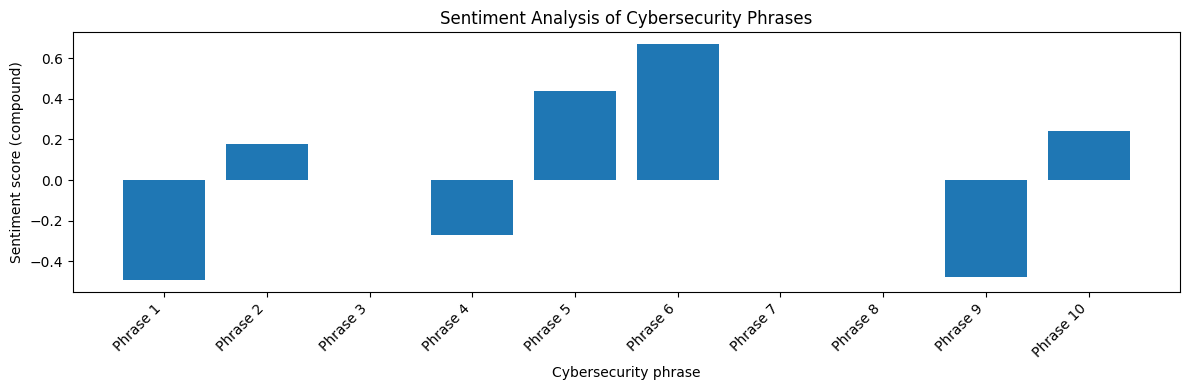

In [18]:
# Install once per environment (you can comment this out after first run)
# !pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

analyzer = SentimentIntensityAnalyzer()

#1 Cybersecurity keywords / phrases
phrases = [
    "critical zero-day vulnerability detected in production",
    "successful ransomware attack on core database",
    "multi-factor authentication rollout completed",
    "phishing campaign blocked by email gateway",
    "unauthorized access to privileged account",
    "security posture improved after patch management overhaul",
    "major data breach affecting customer records",
    "enhanced monitoring reduced incident response time",
    "supply-chain attack discovered in third-party software",
    "penetration test shows no critical findings"
]

#2 Compute sentiment scores
sentiments = []
for txt in phrases:
    score = analyzer.polarity_scores(txt)
    sentiments.append(score["compound"])  # overall sentiment

for p, s in zip(phrases, sentiments):
    print(f"{s: .3f}  |  {p}")

#3 Plot sentiment per phrase
plt.figure(figsize=(12,4))
x = range(len(phrases))
plt.bar(x, sentiments)
plt.xticks(x, [f"Phrase {i+1}" for i in x], rotation=45, ha="right")
plt.xlabel("Cybersecurity phrase")
plt.ylabel("Sentiment score (compound)")
plt.title("Sentiment Analysis of Cybersecurity Phrases")
plt.tight_layout()
plt.show()
